# **Chest X-Ray YOLO Model Training Example**

This notebook is an example demonstrating how to load and explore the Chest X-ray dataset used for training a Deep Learning model. The dataset comprises 112,120 frontal-view X-ray images from 30,805 unique patients. Each image may have multi-label annotations for the following fourteen thoracic pathologies:

- Atelectasis
- Consolidation
- Infiltration
- Pneumothorax
- Edema
- Emphysema
- Fibrosis
- Effusion
- Pneumonia
- Pleural Thickening
- Cardiomegaly
- Nodule
- Mass
- Hernia

The focus of this notebook is solely on data loading and preliminary exploration.

# Clean environment

In [1]:
!rm -rf sample_data
# !rm -rf datasets/data

# Libraries

If you're using Google Colab, just run the next cell. If you're using a local notebook (e.g., inside of VSC), change the cell language mode to Batch or similar.

In [2]:
!pip install huggingface_hub pandas keras

# Getting the dataset

You can either use the complete dataset (more than 40 GB will be needed) or a 17 GB dataset created from the original that is stored on Google Drive and can be mounted in order to load it quickly.

**Important**: The download size of the complete dataset is around 40 GB.

In [3]:
import pandas as pd
import os
import zipfile
import numpy as np
from pathlib import Path
from tqdm.notebook import tqdm
from glob import glob
from itertools import chain
from matplotlib import pyplot as plt

In [4]:
HUGGING_FACE = "hugging_face"
GOOGLE_DRIVE = "google_drive"

# Modify this variable to change the dataset download mode
DATASET_DOWNLOAD_MODE = HUGGING_FACE

if DATASET_DOWNLOAD_MODE == HUGGING_FACE:
    from huggingface_hub import hf_hub_download

    REPO_ID = "alkzar90/NIH-Chest-X-ray-dataset"
    FILEPATH = "data/Data_Entry_2017_v2020.csv"

    datasets_path = Path("datasets/").mkdir(exist_ok=True)
    dataset_path = Path(hf_hub_download(repo_id=REPO_ID, filename=FILEPATH, repo_type="dataset", local_dir="datasets/"))

    # Download images
    for i in range(1, 12+1):
        FILEPATH = f"data/images/images_{i:03d}.zip"
        downloaded_tmp_file = Path("datasets/") / "tmp" / f"zip-{i}-downloaded.tmp"

        if downloaded_tmp_file.exists():
            print(f"{FILEPATH} already exists. Skipping download.")
        else:
            print(f"Downloading {FILEPATH}...")
            zip_path = Path(hf_hub_download(
                repo_id=REPO_ID, filename=FILEPATH, repo_type="dataset", local_dir="datasets/"))

            # Create a temp file that indicates the zip was completely downloaded
            downloaded_tmp_file.mkdir(parents=True, exist_ok=True)
            downloaded_tmp_file.touch()

        extracted_tmp_file = Path("datasets/") / "tmp" / f"zip-{i}-extracted.tmp"
        if extracted_tmp_file.exists():
            print(f"{FILEPATH} already exists. Skipping download.")
        else:
            zipfile.ZipFile(zip_path).extractall("datasets/data/")

            # Create a temp file that indicates the zip was completely extracted
            extracted_tmp_file.mkdir(parents=True, exist_ok=True)
            extracted_tmp_file.touch()

            os.system(f"rm datasets/{FILEPATH}")

            print("ZIP extracted and removed!")

    print("Dataset downloaded and extracted!")

# TODO: Implement Google Drive mount
# elif DATASET_DOWNLOAD_MODE == GOOGLE_DRIVE:
#     from google.colab import drive
#     drive.mount('/content/drive')

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Data_Entry_2017_v2020.csv:   0%|          | 0.00/9.00M [00:00<?, ?B/s]

images_001.zip:   0%|          | 0.00/2.01G [00:00<?, ?B/s]

ZIP extracted and removed!


images_002.zip:   0%|          | 0.00/3.95G [00:00<?, ?B/s]

...

ZIP extracted and removed!


images_011.zip:   0%|          | 0.00/4.19G [00:00<?, ?B/s]

ZIP extracted and removed!


images_012.zip:   0%|          | 0.00/2.91G [00:00<?, ?B/s]

ZIP extracted and removed!
Dataset downloaded and extracted!


# Data Exploration

In [5]:
# !ls datasets/data/images

## Clean and transform the data

In [6]:
csv = pd.read_csv(dataset_path)

# Add an image_path column to the DataFrame
images_paths = {
    os.path.basename(x): x for x in
        glob(os.path.join('.', 'datasets', 'data', 'images', '*.png'))
}

print(f'Found {len(images_paths)} images. Total Rows: {csv.shape[0]}')
csv['image_path'] = csv['Image Index'].map(images_paths.get)

# Remove rows that have a null path
csv.dropna(subset=['image_path'], inplace=True)
print(f"Dropped rows with a null path. {csv.shape[0]} rows remain.")

# Remove 'No Finding' labels from the Finding Labels column
csv['Finding Labels'] = csv['Finding Labels'].map(lambda x: x.replace('No Finding', ''))

# Get all labels ['Label1', 'Label3', 'Label1', ...]
all_labels = list(chain(*csv['Finding Labels'].map(lambda x: x.split('|')).tolist()))
# Get unique {'Label1', 'Label2', 'Label3', ...}
all_labels = list(set(all_labels))
# Remove empty string label
all_labels.remove('')

# Add each label as a column and set 1 if the label was assigned to the image;
# otherwise, set 0.
for label in all_labels:
    csv[label] = csv['Finding Labels'].map(lambda finding_labels: 1 if label in finding_labels else 0)

print(csv.sample(3))

print(
    '{} Labels\n{}'.format(
      len(all_labels),
      "\n".join([f"{label}: {int(csv[label].sum())}" for label in all_labels]),
    )
)

Found 112120 images. Total Rows: 112120
Dropped rows with a null path. 112120 rows remain.
            Image Index                                     Finding Labels  \
12233  00003190_016.png                                                      
55582  00013917_020.png  Consolidation|Effusion|Infiltration|Mass|Pneum...   
57187  00014198_002.png                                        Atelectasis   

       Follow-up #  Patient ID  Patient Age Patient Gender View Position  \
12233            3        3190           39              F            PA   
55582           18       13917           54              M            AP   
57187            2       14198           24              F            AP   

       OriginalImage[Width  Height]  OriginalImagePixelSpacing[x  ...  \
12233                 2670     2825                        0.143  ...   
55582                 2500     2048                        0.168  ...   
57187                 2500     2048                        0.168  ...   

## Resampling the highly unbalanced dataset
Since the dataset is very unbalanced (there are WAY more healthy patients than patients with diseases, and some diseases are more common than others), we can resample it to be a more reasonable collection, so that the model doesn't pay more attention to the most common labels.

Weight is `0.04 + number of findings` for each label.

### Distribution before resampling

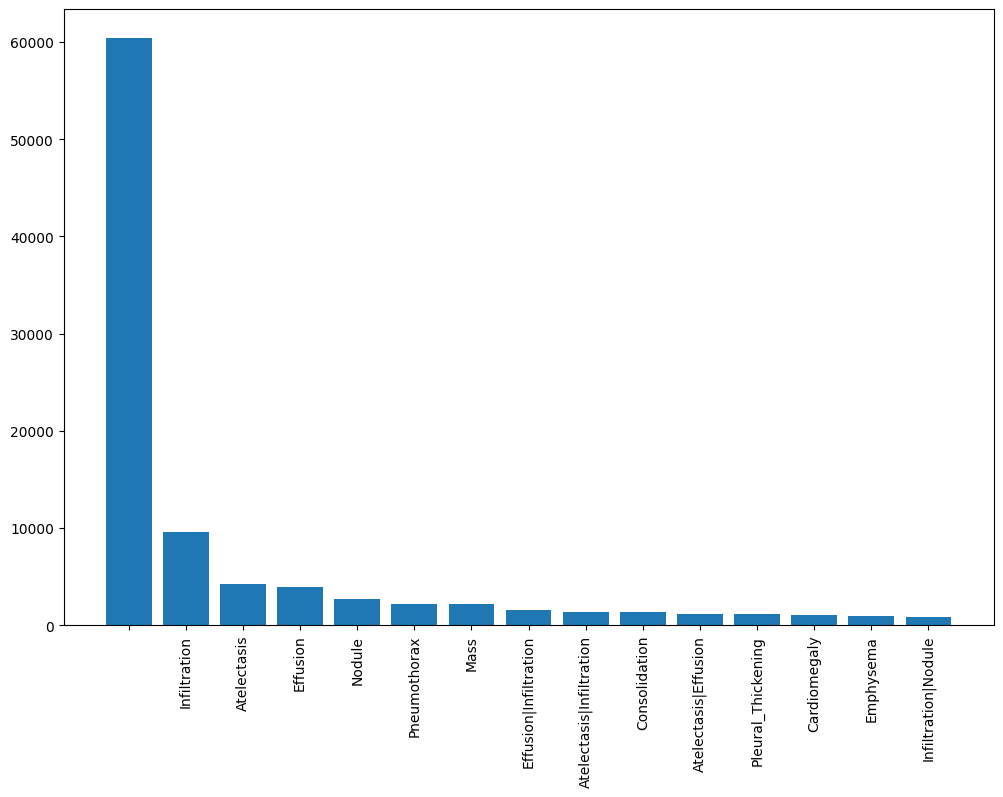

In [7]:
label_counts = csv['Finding Labels'].value_counts()[:15]
fig, ax1 = plt.subplots(1,1,figsize = (12, 8))
ax1.bar(np.arange(len(label_counts)) + 0.5, label_counts)
ax1.set_xticks(np.arange(len(label_counts)) + 0.5)
_ = ax1.set_xticklabels(label_counts.index, rotation = 90)

In [8]:
sample_weights = csv['Finding Labels'].map(
    lambda x: len(x.split('|')) if len(x)>0 else 0
).values + 4e-2
sample_weights /= sample_weights.sum()

# # If you want to see the weight of each row:
# for index, weight in enumerate(sample_weights):
#   print(f"Row {index}| Weight: {weight}")
# print(f"Length of sample weights: {len(sample_weights)}")
# print(f"Number of rows in dataset: {csv.shape[0]}")

sampled_df = csv.sample(csv.shape[0] // 2, weights=sample_weights)

### Distribution after resampling

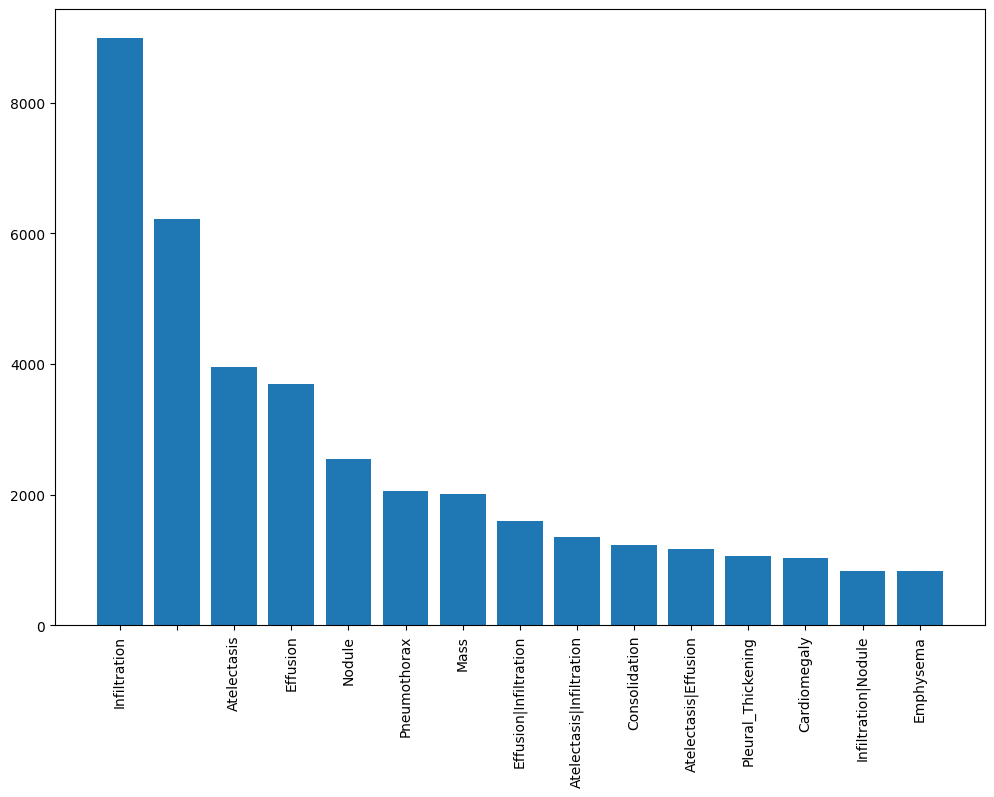

In [9]:
label_counts = sampled_df['Finding Labels'].value_counts()[:15]
fig, ax1 = plt.subplots(1,1,figsize = (12, 8))
ax1.bar(np.arange(len(label_counts)) + 0.5, label_counts)
ax1.set_xticks(np.arange(len(label_counts)) + 0.5)
_ = ax1.set_xticklabels(label_counts.index, rotation = 90)

### Delete images that are not in the dataframe returned from sampling

In [10]:
# Get images from the original dataframe that are not sampled
images_to_delete = csv[~csv["image_path"].isin(sampled_df["image_path"])]["image_path"].values

# Delete images
for image_path in tqdm(images_to_delete):
    if os.path.isfile(image_path):
        os.remove(image_path)

  0%|          | 0/56060 [00:00<?, ?it/s]

## Create a column containing the diseases as a list


In [11]:
sampled_df['disease_vec'] = sampled_df.apply(lambda x: [x[all_labels].values], 1).map(lambda x: x[0])
print(sampled_df["disease_vec"])

5149      [0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0]
80471     [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
106105    [1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
52362     [0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0]
20035     [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
                             ...                    
9026      [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
52164     [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
69163     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0]
9917      [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
79105     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Name: disease_vec, Length: 56060, dtype: object


## Split the dataset

In [12]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(sampled_df,
                                   test_size = 0.15,
                                   random_state = 86196,
                                   stratify = sampled_df['Finding Labels'].map(lambda x: x[:4]))

train_df, validation_df = train_test_split(train_df,
                                   test_size = 0.10,
                                   random_state = 47941,
                                   stratify = train_df['Finding Labels'].map(lambda x: x[:4]))

print('Train:', train_df.shape[0], 'Validation:', validation_df.shape[0], 'Test:', test_df.shape[0])

Train: 42885 Validation: 4766 Test: 8409


## Get datasets of images

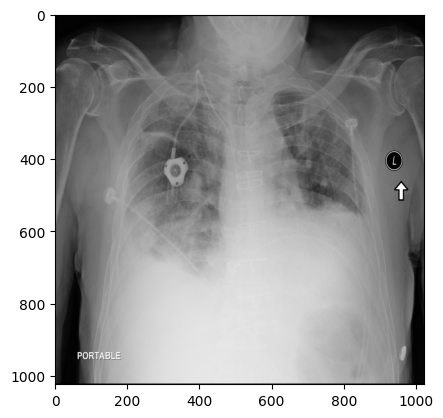

In [13]:
# Read an image using cv2
import cv2
img = cv2.imread(train_df["image_path"].iloc[0])

# Show using matplotlib
plt.imshow(img)

In [14]:
import tensorflow as tf

IMAGE_SIZE = (640, 640)

def load_and_preprocess_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image)
    image = tf.image.resize(image, IMAGE_SIZE)
    image = tf.image.convert_image_dtype(image, dtype=tf.float32)
    return image, label

def get_images_dataset_from_dataframe(dataframe: pd.DataFrame,
        path_column: str, y_column: str, batch_size: int) -> tf.data.Dataset:
    """Both Tensorflow's image_dataset_from_directory and
    ImageGenerator.flow_from_directory are deprecated and need the number of
    images in the directory and the number of labels to be the same,
    so the datasets are created manually using Tensorflow's Dataset class."""
    # Create a Dataset from image paths and labels
    image_paths = dataframe[path_column].values
    labels = (dataframe[y_column].values)
    # cast labels into lists using numpy functions
    labels = np.array(labels.tolist(), dtype=np.uint32).tolist()

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    dataset = dataset.map(
        load_and_preprocess_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # Apply batching and batches prefetching
    dataset = dataset.batch(
        batch_size=batch_size,
        num_parallel_calls=tf.data.AUTOTUNE,
    ).prefetch(buffer_size=tf.data.AUTOTUNE)

    return dataset

In [15]:
train_dataset = get_images_dataset_from_dataframe(
    train_df,
    path_column="image_path",
    y_column="disease_vec",
    batch_size=16,
)
validation_dataset = get_images_dataset_from_dataframe(
    validation_df,
    path_column="image_path",
    y_column="disease_vec",
    batch_size=32,
)
test_dataset = get_images_dataset_from_dataframe(
    test_df,
    path_column="image_path",
    y_column="disease_vec",
    batch_size=64,
)

## Visualize the images from the datasets

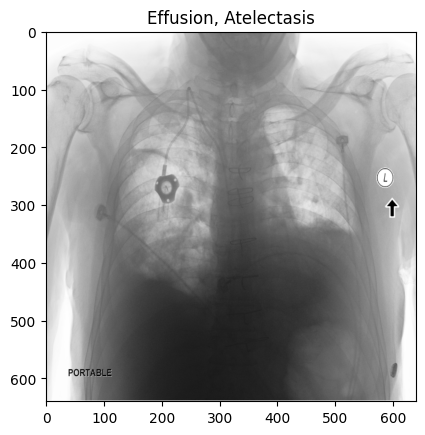

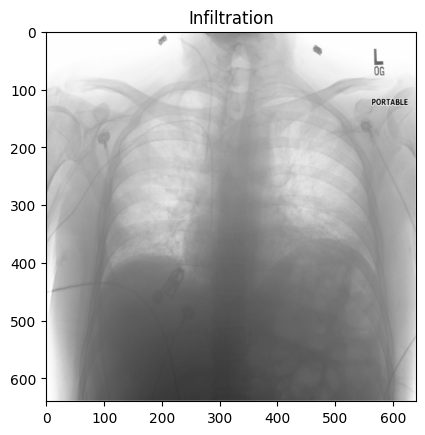

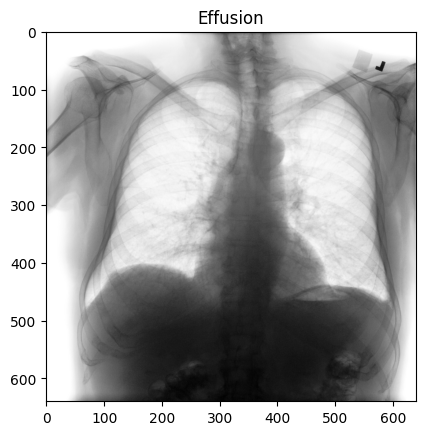

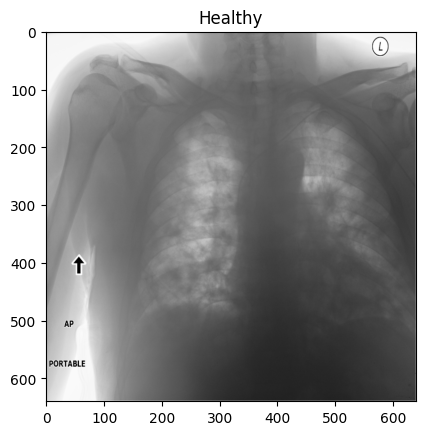

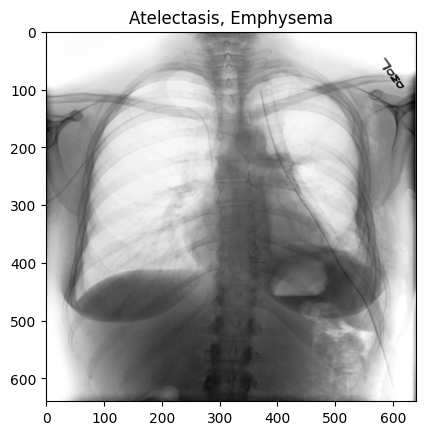

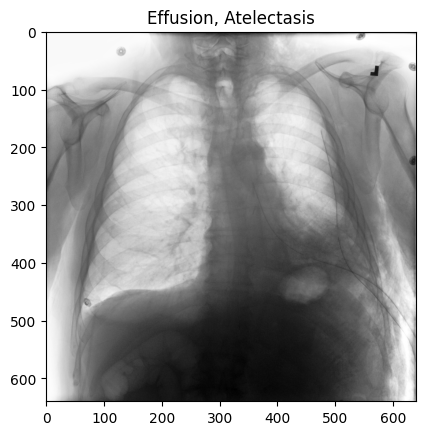

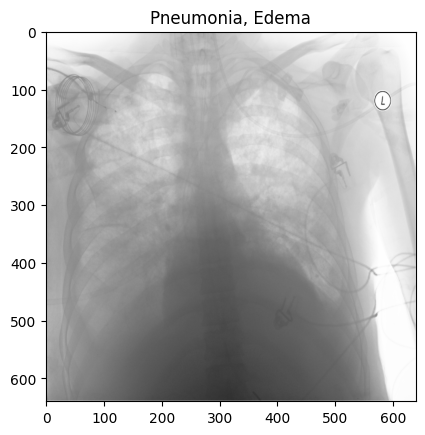

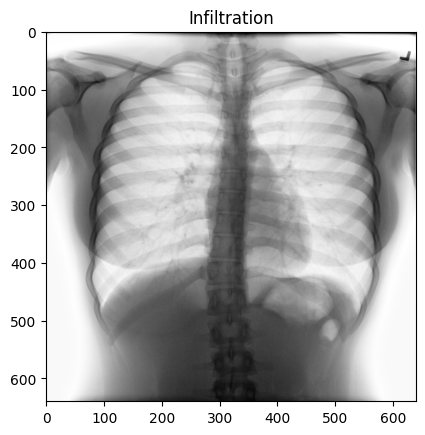

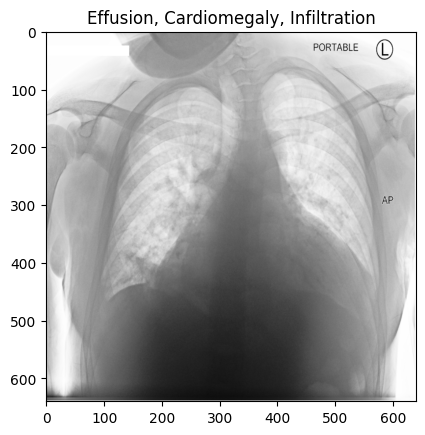

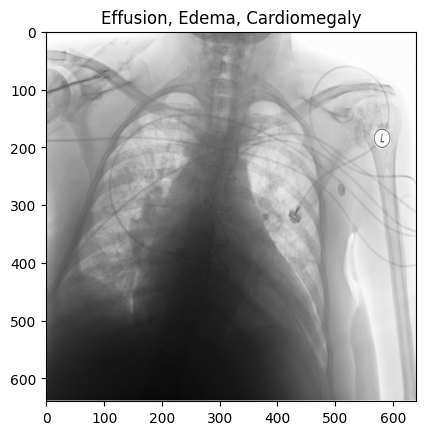

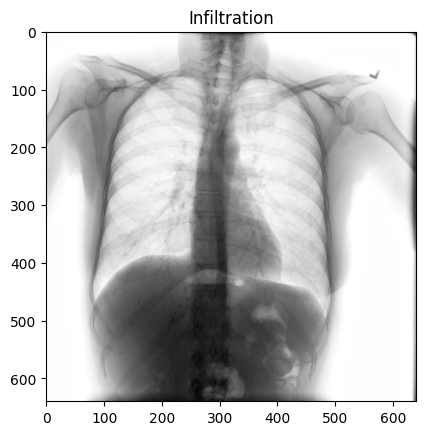

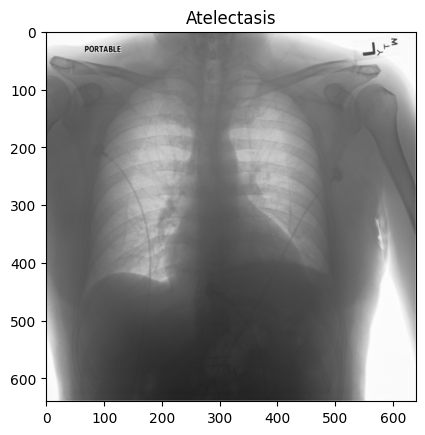

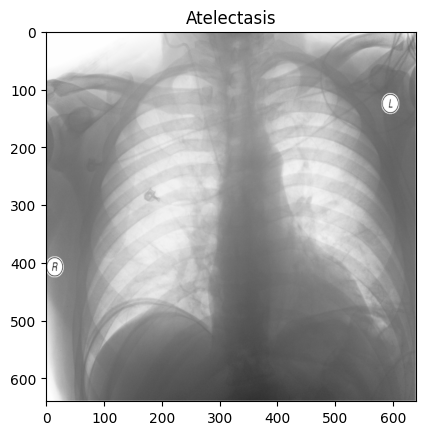

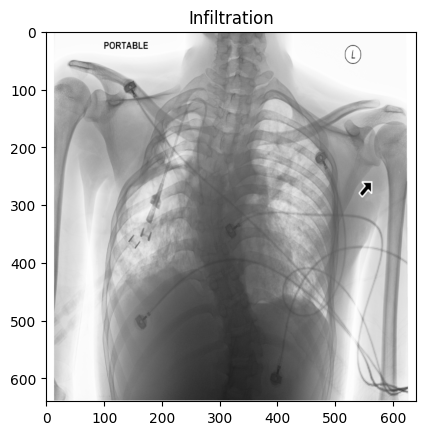

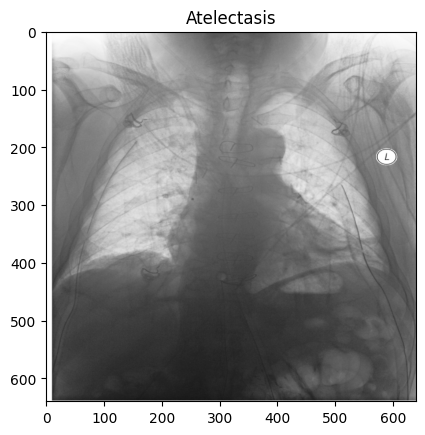

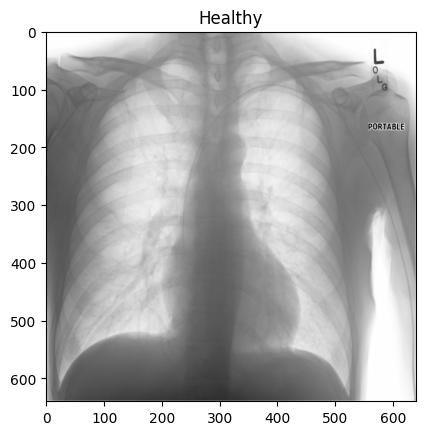

In [29]:
for image, labels in train_dataset.take(1).as_numpy_iterator():
    for image, label in zip(image, labels):
        # Get all the Finding Labels corresponding to this image
        # using the label variable which is one-hot coded
        finding_labels = [all_labels[i] for i, l in enumerate(label) if l == 1]

        # If there are no labels, the patient is healthy
        if len(finding_labels) == 0:
            finding_labels = ["Healthy"]

        # Show image, being the title the labels as strings
        plt.imshow(image, cmap="Greys")
        plt.title(", ".join(finding_labels))
        plt.show()